In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "../Data Collection + Processing/data/processed/"

## Phân tích file `training_dataset_labeled.csv`

In [3]:
df_train = pd.read_csv(DATA_PATH + 'training_dataset_labeled.csv')

In [4]:
df_train = df_train.drop(columns=['status_raw', 'route_airport'])

In [5]:
df_train.head()

,retrieved_at_vn,flight_date,direction,scheduled_time,estimated_time,flight_number,source_airport,route_airport_std,status_group,scheduled_dt,...,is_wind_variable,scheduled_hour,scheduled_dayofweek,scheduled_month,airline_code,flight_num_only,minutes_to_departure_at_snapshot,is_estimated_missing,temp_dew_spread,is_low_visibility
0,2026-04-09 23:39:16,2026-04-09,Arrival,07:05,06:57,QH101,DN,HA NOI (HAN),on_time,2026-04-09 07:05:00,...,1,7,3,4,QH,101,-994.266667,0,4,0.0
1,2026-04-09 23:39:16,2026-04-09,Departure,13:40,13:40,VN129,DN,HO CHI MINH (SGN),other,2026-04-09 13:40:00,...,1,13,3,4,VN,129,-599.266667,0,4,0.0
2,2026-04-09 23:39:16,2026-04-09,Departure,13:20,13:40,9G922,DN,HA NOI (HAN),other,2026-04-09 13:20:00,...,1,13,3,4,9G,9,-619.266667,0,4,0.0
3,2026-04-09 23:39:16,2026-04-09,Departure,13:20,13:20,VJ703,DN,CAN THO (VCA),other,2026-04-09 13:20:00,...,1,13,3,4,VJ,703,-619.266667,0,4,0.0
4,2026-04-09 23:39:16,2026-04-09,Departure,13:15,13:15,VJ510,DN,HA NOI (HAN),other,2026-04-09 13:15:00,...,1,13,3,4,VJ,510,-624.266667,0,4,0.0


status_raw -> status_group,  route_airpot -> route_airport_std 

### Tổng quan dữ liệu

In [6]:
print(f"Số lượng dòng: {df_train.shape[0]}")
print(f"Số lượng cột: {df_train.shape[1]}")
print(df_train.info())

Số lượng dòng: 2131
Số lượng cột: 33
<class 'pandas.DataFrame'>
RangeIndex: 2131 entries, 0 to 2130
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   retrieved_at_vn                   2131 non-null   str    
 1   flight_date                       2131 non-null   str    
 2   direction                         2131 non-null   str    
 3   scheduled_time                    2131 non-null   str    
 4   estimated_time                    2084 non-null   str    
 5   flight_number                     2131 non-null   str    
 6   source_airport                    2131 non-null   str    
 7   route_airport_std                 2131 non-null   str    
 8   status_group                      2131 non-null   str    
 9   scheduled_dt                      2131 non-null   str    
 10  estimated_dt                      2084 non-null   str    
 11  delay_minutes                     2084 non-

### Giá trị bị thiếu

In [7]:
# Liệt kê các cột có giá trị thiếu và tỷ lệ %
missing = df_train.isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print(pd.DataFrame({'Số lượng': missing, 'Tỷ lệ (%)': (missing/len(df_train)*100).round(2)}))
else:
    print("Không có giá trị thiếu.")

                    Số lượng  Tỷ lệ (%)
estimated_time            47       2.21
estimated_dt              47       2.21
delay_minutes             47       2.21
wind_direction_deg       135       6.34


$\rightarrow$ cột `wind_direction_deg` thiếu **6%**. Nên kiểm tra xem có cột thiếu này có liên quan đến việc trễ chuyến hay là nhân tố nào không và có các biện pháp điền vào các chỗ thiếu này.

### Dữ liệu trùng lặp

In [8]:
duplicate_count = df_train.duplicated().sum()
print(f"Số lượng dòng trùng lặp: {duplicate_count}")

Số lượng dòng trùng lặp: 0


### Thống kê mô tả

In [9]:
desc = df_train.describe().T
print(desc.to_markdown())

|                                  |   count |          mean |         std |      min |      25% |      50% |     75% |      max |
|:---------------------------------|--------:|--------------:|------------:|---------:|---------:|---------:|--------:|---------:|
| delay_minutes                    |    2084 |     3.92035   |   17.3555   |   -32    |     0    |    0     |    5    |  425     |
| label_delay                      |    2131 |     0.149226  |    0.356394 |     0    |     0    |    0     |    0    |    1     |
| temperature_c                    |    2131 |    28.9244    |    1.23768  |    27    |    28    |   30     |   30    |   30     |
| dew_point_c                      |    2131 |    24.8057    |    0.582842 |    22    |    25    |   25     |   25    |   25     |
| wind_direction_deg               |    1996 |   103.011     |   18.5489   |    80    |    80    |  110     |  110    |  160     |
| wind_speed_kt                    |    2131 |     7.05866   |    2.52031  |     2 

- **Outliers**: ở cột `delay_minutes`, giá trị Max là 425 phút trong khi 75% giá trị của cột này đề dưới 5 phút.

- Ở đây ta thấy có 1 feature là `is_low_visibility` đều toàn số 0 vì do đã set logic là biến sẽ = 1 khi `visibility_miles < 3`. Chưa cần phải xoá -> có thể có lợi cho dữ liệu được lấy từ lần sau.

- Bất cập trong thu thập dữ liệu: Cột `minutes_to_departure_at_snapshot` có giá trị âm chiếm đa số (Mean ~ -1140). Điều này cho thấy phần lớn dữ liệu được thu thập sau khi chuyến bay đã khởi hành.
    - Nhận xét: Nếu dùng để dự báo thời gian thực, cần lọc lại chỉ lấy các dòng có giá trị dương (dữ liệu thu thập trước giờ bay).

- Các cột có miền giá trị khác nhau $\rightarrow$ cần scale lại giá trị trước khi đưa vào mô hình

### Độ đa dạng của các cột Categorical

In [10]:
categorical_cols = df_train.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    print(f"{col:<18}: {df_train[col].nunique():>4} giá trị khác nhau")

retrieved_at_vn   :   13 giá trị khác nhau
flight_date       :    5 giá trị khác nhau
direction         :    2 giá trị khác nhau
scheduled_time    :  213 giá trị khác nhau
estimated_time    :  652 giá trị khác nhau
flight_number     :  456 giá trị khác nhau
source_airport    :    3 giá trị khác nhau
route_airport_std :   25 giá trị khác nhau
status_group      :    6 giá trị khác nhau
scheduled_dt      :  960 giá trị khác nhau
estimated_dt      : 1442 giá trị khác nhau
icao_code         :    3 giá trị khác nhau
report_time_utc   :    2 giá trị khác nhau
report_time_vn    :    2 giá trị khác nhau
cloud_cover       :    4 giá trị khác nhau
raw_metar         :    6 giá trị khác nhau
airline_code      :   11 giá trị khác nhau


1. Nhóm Low Cardinality
- `direction`, `source_airport`, `icao_code` có độ đa dạng thấp -> có thể One-hot Encoding

- `airline_code` là số lượng hãng bay được dùng để thay thế cho `flight_number` số hiệu chuyến bay

2. Nhóm dữ liệu thời gian
- `scheduled_dt` (960 giá trị), `estimated_dt` (1442 giá trị) -> Không đưa trực tiếp vào mô hình, sẽ dùng các cột được tách sẵn như `scheduled_hour`. `scheduled_dayofweek` có độ đa dạng thấp và mang tính quy luật hơn.

In [11]:
for col in categorical_cols:
    print(f"\n===== PHÂN TÍCH CỘT: {col.upper()} =====")
    print(f"Số lượng giá trị duy nhất: {df_train[col].nunique()}")
    
    # In ra Top 10 giá trị xuất hiện nhiều nhất và số lần xuất hiện
    print("Top 10 giá trị phổ biến nhất:")
    print(df_train[col].value_counts().head(10))
    
    # Kiểm tra xem có giá trị nào trông giống 'rác' (số, kí tự lạ) không
    # Ví dụ: in thử 5 giá trị ngẫu nhiên
    print("Mẫu 5 giá trị bất kỳ:")
    print(df_train[col].sample(min(5, df_train[col].nunique())).values)
    print("-" * 30)


===== PHÂN TÍCH CỘT: RETRIEVED_AT_VN =====
Số lượng giá trị duy nhất: 13
Top 10 giá trị phổ biến nhất:
retrieved_at_vn
2026-04-12 19:25:26    283
2026-04-12 19:26:21    283
2026-04-13 15:42:25    263
2026-04-12 19:26:09    256
2026-04-09 23:40:13    253
2026-04-12 19:27:17    142
2026-04-12 19:24:50    140
2026-04-13 15:41:54    138
2026-04-09 23:39:16    135
2026-04-12 19:26:38    134
Name: count, dtype: int64
Mẫu 5 giá trị bất kỳ:
<StringArray>
['2026-04-12 19:26:21', '2026-04-12 19:26:38', '2026-04-12 19:23:53',
 '2026-04-12 19:26:38', '2026-04-12 19:26:21']
Length: 5, dtype: str
------------------------------

===== PHÂN TÍCH CỘT: FLIGHT_DATE =====
Số lượng giá trị duy nhất: 5
Top 10 giá trị phổ biến nhất:
flight_date
2026-04-12    469
2026-04-13    441
2026-04-10    423
2026-04-09    408
2026-04-11    390
Name: count, dtype: int64
Mẫu 5 giá trị bất kỳ:
<StringArray>
['2026-04-12', '2026-04-11', '2026-04-12', '2026-04-11', '2026-04-09']
Length: 5, dtype: str
----------------------

### Độ mất cân bằng của Label

In [12]:
print(df_train['label_delay'].value_counts(normalize=True) * 100)

label_delay
0    85.077428
1    14.922572
Name: proportion, dtype: float64


$\rightarrow$ Dữ liệu bị mất cân bằng, tỉ lệ trễ (15%) và tỉ lệ đúng giờ (85%)

### Phân tích cột `deplay_minutes` của mô hình

--- Phân tích dòng thiếu delay_minutes ---
status_group
on_time    39
landed      8
Name: count, dtype: int64


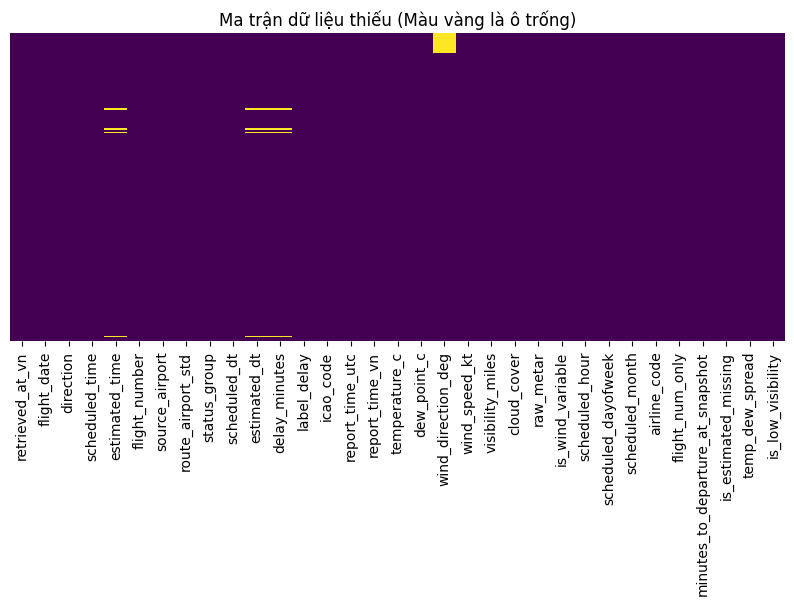

In [13]:
missing_delay = df_train[df_train['delay_minutes'].isnull()]
print("--- Phân tích dòng thiếu delay_minutes ---")
print(missing_delay['status_group'].value_counts())

# Trực quan hóa ma trận dữ liệu thiếu (để xem các cột có thiếu cùng lúc không)
plt.figure(figsize=(10, 4))
sns.heatmap(df_train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Ma trận dữ liệu thiếu (Màu vàng là ô trống)')
plt.show()

Các dòng `deplay_minutes` bị thiếu nhưng đều có `status_raw` là `Đúng giờ` hoặc `Đã hạ cánh` -> Có thể là bot chưa cập nhật được dữ liệu về các chuyến bay này cho nên bị thiếu `deplay_minutes` ở các dòng này. Không ảnh hưởng quá lớn đến dataset

### Phân tích Phân phối và Độ lệch

Skewness của delay_minutes: 9.17
Skewness của temperature_c: -0.43
Skewness của wind_speed_kt: -0.68
Skewness của visibility_miles: -2.36
Skewness của scheduled_hour: -0.14


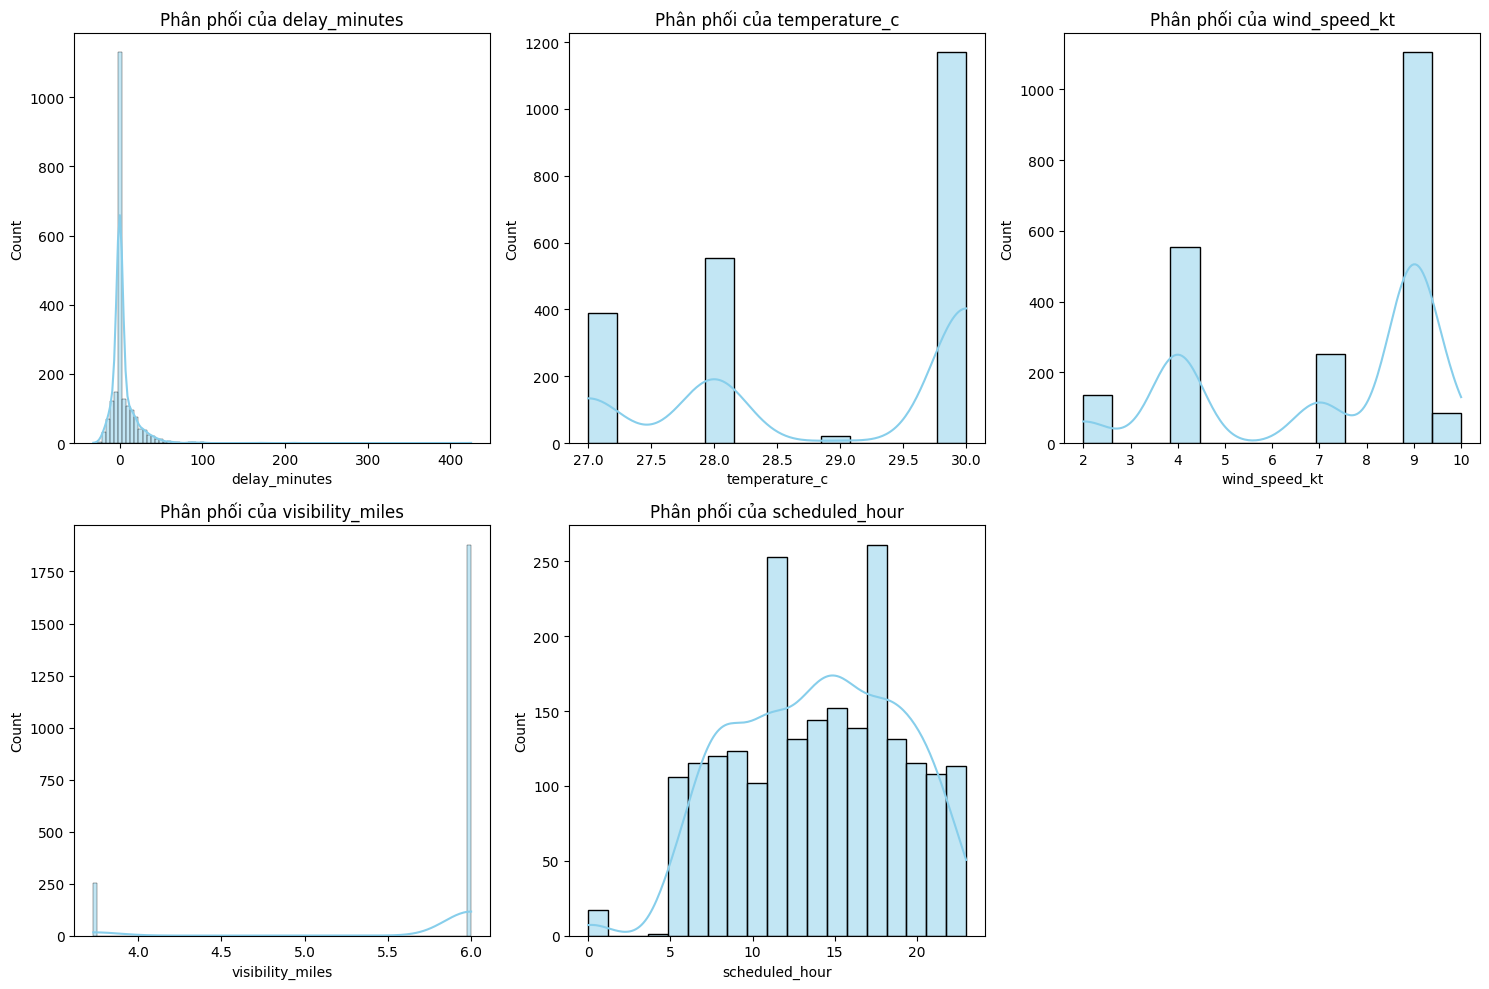

In [14]:
# Danh sách các cột số cần kiểm tra
num_cols = ['delay_minutes', 'temperature_c', 'wind_speed_kt', 'visibility_miles', 'scheduled_hour']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_train[col], kde=True, color='skyblue')
    plt.title(f'Phân phối của {col}')
    # Tính độ lệch (Skewness)
    print(f"Skewness của {col}: {df_train[col].skew():.2f}")

plt.tight_layout()
plt.show()

`delay_minutes`: Log Transform + RobustScaler (để giảm ảnh hưởng Outliers).

`visibility_miles`: Cân nhắc Binning (chia nhóm: Tốt / Trung bình / Xấu) vì dữ liệu quá lệch.

`scheduled_hour` : Giữ nguyên hoặc dùng Sine/Cosine Transform (để máy hiểu 23h và 0h là gần nhau).

`temperature_c` : Standard Scaling.

### Kiểm tra tính Logic

In [15]:
print("--- Kiểm tra tính Logic ---")

# 1. Nhiệt độ không thể thấp hơn điểm sương (vật lý)
physics_error = df_train[df_train['temperature_c'] < df_train['dew_point_c']]
print(f"Số dòng lỗi Nhiệt độ < Điểm sương: {len(physics_error)}")

# 2. Kiểm tra những chuyến bay 'đúng giờ' (label 0) nhưng số phút trễ lại quá lớn
logic_error = df_train[(df_train['label_delay'] == 0) & (df_train['delay_minutes'] > 15)]
print(f"Số dòng lỗi Label=0 nhưng trễ > 15p: {len(logic_error)}")

--- Kiểm tra tính Logic ---
Số dòng lỗi Nhiệt độ < Điểm sương: 0
Số dòng lỗi Label=0 nhưng trễ > 15p: 0


### Phát hiện Bất thường

C:\Users\vnviv\AppData\Local\Temp\ipykernel_3120\1833256585.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='airline_code', y='delay_minutes', data=df_train, palette='Set3')


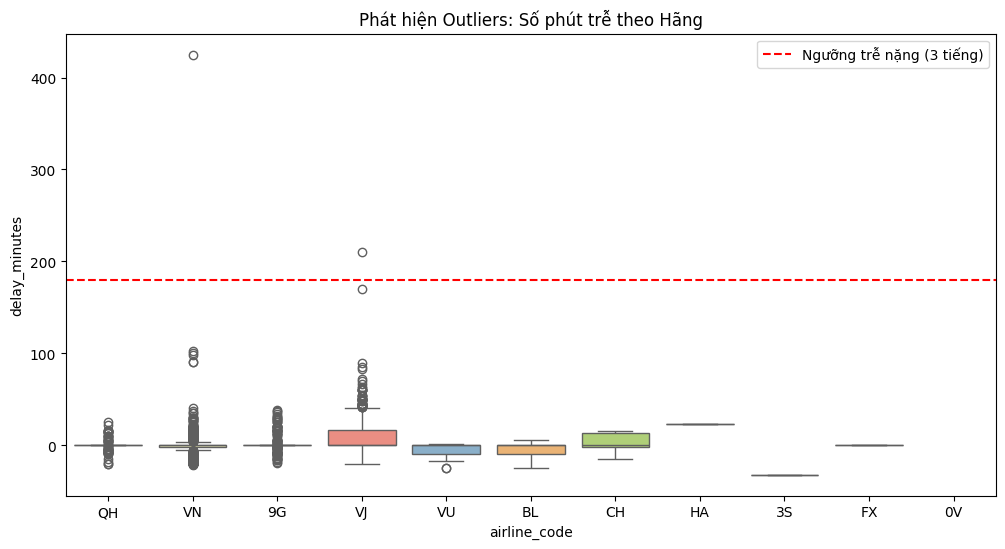

--- Top 5 chuyến bay trễ nhất ---
|      | flight_number   |   delay_minutes | status_group   | raw_metar                                                       |
|-----:|:----------------|----------------:|:---------------|:----------------------------------------------------------------|
| 1341 | VN7207          |             425 | departed       | METAR VVNB 121200Z 11009KT 9999 FEW019 OVC043 30/25 Q1002 NOSIG |
|  138 | VJ1504          |             210 | other          | METAR VVDN 121200Z 08004KT 9999 FEW020 28/25 Q1006 NOSIG        |
|  196 | VJ528           |             170 | other          | METAR VVDN 121200Z 08004KT 9999 FEW020 28/25 Q1006 NOSIG        |
| 1376 | VN212           |             102 | landed         | METAR VVNB 121200Z 11009KT 9999 FEW019 OVC043 30/25 Q1002 NOSIG |
| 1227 | VN209           |             100 | departed       | METAR VVNB 121200Z 11009KT 9999 FEW019 OVC043 30/25 Q1002 NOSIG |


In [16]:
plt.figure(figsize=(12, 6))

# Vẽ Boxplot cho số phút trễ theo Hãng hàng không
sns.boxplot(x='airline_code', y='delay_minutes', data=df_train, palette='Set3')
plt.axhline(y=180, color='red', linestyle='--', label='Ngưỡng trễ nặng (3 tiếng)')
plt.title('Phát hiện Outliers: Số phút trễ theo Hãng')
plt.legend()
plt.show()

# Lọc ra danh sách 5 chuyến bay trễ "kinh khủng" nhất để inspect
outliers_top = df_train.nlargest(5, 'delay_minutes')[['flight_number', 'delay_minutes', 'status_group', 'raw_metar']]
print("--- Top 5 chuyến bay trễ nhất ---")
print(outliers_top.to_markdown())

### Phân tích tương quan

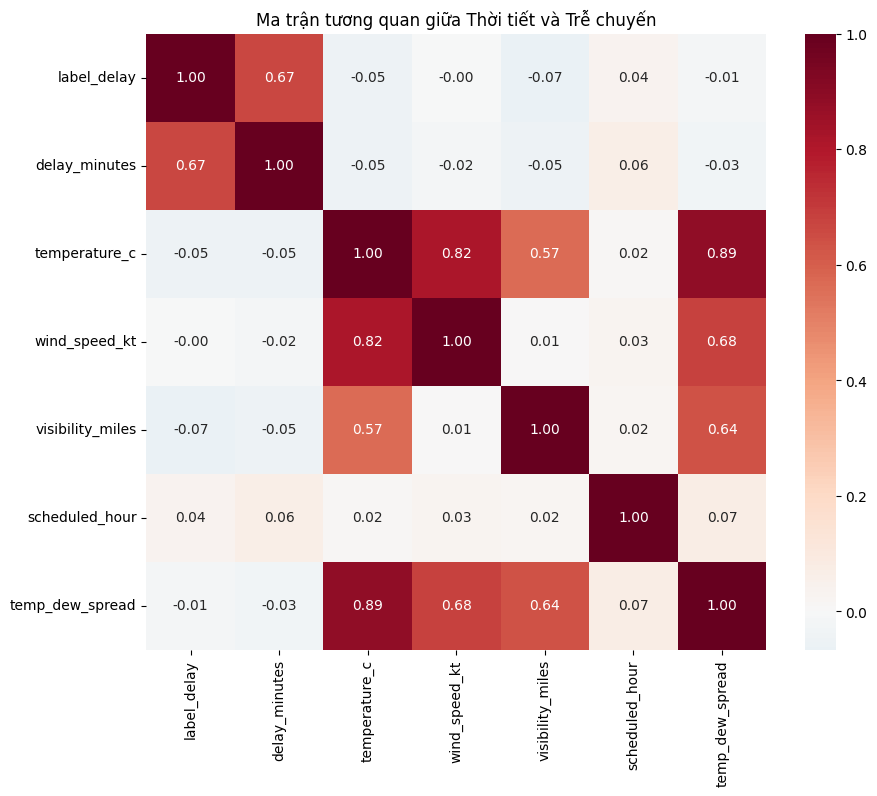

In [17]:
# Chọn các cột số quan trọng
corr_cols = ['label_delay', 'delay_minutes', 'temperature_c', 'wind_speed_kt', 
             'visibility_miles', 'scheduled_hour', 'temp_dew_spread']

plt.figure(figsize=(10, 8))
correlation_matrix = df_train[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Ma trận tương quan giữa Thời tiết và Trễ chuyến')
plt.show()